# 🧑‍🤝‍🧑 ***Team 11 :***


🧑‍💻 Waghmode Pruthviraj Sanjay , 25AI10019

🧑‍💻 Vidwathkalpa Gundaram , 25AI10018

🧑‍💻 Kunal Kumar , 25AI10005


# **Crop Recommendation System**


# 📄**Problem Statement**

Agriculture is a vital sector that supports food production and the livelihood of millions of people. One of the key decisions farmers must make is choosing the most suitable crop to grow based on soil nutrients and environmental conditions. Farmers often select crops based on traditional knowledge or experience, which may not always match the current soil and climatic conditions. This can result in lower crop yield and inefficient use of agricultural resources.

 ***Project Objective***

The goal is to predict the best crop based on soil nutrients and environmental conditions.

 ***Key Objectives***

- Study the effect of environmental factors on crop growth

- Build a machine learning model for crop recommendation

- Assist farmers in maximizing yield and sustainability

## ⬇️ Importing required library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

import plotly.io as pio
pio.renderers.default = 'colab'

The above Libraries are for Unlocking the Widget Manager

# Importing dataset

In [ ]:
!git clone https://github.com/Kunal-Kumar42/crop_recommendation


fatal: destination path 'crop_recommendation' already exists and is not an empty directory.


In [ ]:
data = '/content/crop_recommendation/crop_recommendation.csv'
df = pd.read_csv(data)

# Introduction to the Dataset

📊 **About the Dataset**

This dataset from Kaggle contains soil and environmental parameters to recommend the most suitable crop for cultivation.

It helps understand the relationship between soil, climate, and crop suitability, making it ideal for building data-driven crop recommendation systems.


📑 **Dataset Attributes**

🌿 Soil Nutrients

- Nitrogen (N): Leaf growth and plant development

- Phosphorus (P): Root growth and flowering

- Potassium (K): Disease resistance and overall health

🌤 Environmental Factors

- Temperature: Average °C for crop growth

- Humidity: Influences transpiration and moisture

- pH: Soil acidity/alkalinity

- Rainfall: Water availability

🌾 **Target Variable**

- Label (Crop): Most suitable crop for the given soil and climate

📈 **Dataset Characteristics**

* Multiple samples across different soil and climate conditions

* Numerical features for environmental measurements

* Designed for multi-class classification

🌍 **Applications & Importance**

🌾 Crop recommendation systems for farmers

🌱 Improve productivity and promote sustainable agriculture

📊 Assist farmers in data-driven crop selection decisions

## Understanding the data

In [ ]:
df.sample(5)

,N,P,K,temperature,humidity,ph,rainfall,label
1512,13.0,126.0,204.0,23.109427,92.796308,6.383180,108.183792,apple
2172,111.0,29.0,31.0,26.059684,52.310985,6.136287,161.343254,coffee
1177,40.0,16.0,35.0,31.893563,49.024501,6.484152,89.593715,mango
125,79.0,51.0,16.0,25.337977,68.498360,6.586245,96.463802,maize
2103,108.0,24.0,31.0,24.128325,56.181077,6.431900,147.275782,coffee


In [ ]:
df.shape

(2200, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2092 non-null   float64
 1   P            2072 non-null   float64
 2   K            2108 non-null   float64
 3   temperature  2123 non-null   float64
 4   humidity     2064 non-null   float64
 5   ph           2090 non-null   float64
 6   rainfall     2079 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(7), object(1)
memory usage: 137.6+ KB


* Statistical Analysis of Data (excluding label)

In [ ]:
description_df = df.describe()

# Calculate skewness and kurtosis for numerical columns
skewness_values = df.drop(columns=['label'], axis=1).skew()
kurtosis_values = df.drop(columns=['label'], axis=1).kurt()

# Add skewness and kurtosis as new rows to the descriptive statistics DataFrame
description_df.loc['skew'] = skewness_values
description_df.loc['kurt'] = kurtosis_values

description_df

,N,P,K,temperature,humidity,ph,rainfall
count,2092.000000,2072.000000,2108.000000,2123.000000,2064.000000,2090.000000,2079.000000
mean,50.423040,53.281853,48.449241,25.622103,71.568847,6.471544,103.155890
std,36.999868,33.088365,50.949259,5.077329,22.146467,0.779163,54.858151
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.750000,22.779952,60.417708,5.966047,64.489063
50%,37.000000,51.000000,32.000000,25.600337,80.483245,6.426829,94.681803
75%,85.000000,68.000000,49.000000,28.561810,89.827940,6.925182,122.801074
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117
skew,0.509296,1.015120,2.353836,0.178859,-1.107023,0.281574,0.983569
kurt,-1.064151,0.859536,4.326644,1.259021,0.353468,1.637873,0.672993


* These detailed statistics reveal that N, P, and K, along with environmental factors, have distinct distributions crucial for crop suitability.
* P and K, especially K, exhibit highly skewed and kurtotic distributions. This means that while many crops need moderate levels, a distinct set of crops require exceptionally high concentrations, making these nutrients critical discriminators for crop recommendation.
* Temperature, humidity, pH, and rainfall also show variations, but generally with less extreme skewness and kurtosis compared to P and K.
* The diverse distributions (some nearly normal, others highly skewed) highlight why simple mean/median imputation might not be ideal and reinforce the choice of KNN imputation to preserve the underlying data patterns

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicate value present in it

In [ ]:
#Checking missing values
df.isnull().mean()

,0
N,0.049091
P,0.058182
K,0.041818
temperature,0.035000
humidity,0.061818
ph,0.050000
rainfall,0.055000
label,0.000000


* The dataset contains 2200 observations and 8 features, including 7 numerical attributes (N, P, K, temperature, humidity, pH, rainfall) and 1 categorical attribute (crop label).
* The dataset represents soil nutrients and environmental conditions, which are important factors affecting crop growth and selection.
* The statistical summary shows that each attribute has a wide range of values, indicating that the dataset contains diverse soil and environmental conditions.
* The dataset contains no duplicate records, which means every row represents a unique observation.
* A small percentage of missing values (~4.4%) is present in the numerical attributes. Since the proportion is low, imputation techniques can effectively handle them without significantly affecting the dataset.


In [ ]:
Original_dataset = df.copy()         #Storing original dataset

##Crop Distribution in Dataset

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# Count the labels
counts = df['label'].value_counts().sort_index()

# Define colors
dot_color = 'lightgrey'
stem_color = '#FF66A3'
hover_bg_color = '#222222'
hover_border_color = '#FFFFFF'

# Create lollipop chart
fig = go.Figure()

# Add stems (lines)
for i, val in enumerate(counts.values):
    fig.add_shape(
        type="line",
        x0=i, y0=0, x1=i, y1=val,
        line=dict(color=stem_color, width=3)
    )

# Add dots
fig.add_trace(go.Scatter(
    x=list(range(len(counts))),
    y=counts.values,
    mode='markers',
    marker=dict(color=dot_color, size=20),
    text=[f"{label}<br>{count}" for label, count in zip(counts.index, counts.values)],
    hoverinfo='text'
))

# Dark theme layout
fig.update_layout(
    title="Crop Distribution - Interactive Lollipop Chart",
    yaxis_title="Count",
    xaxis_title="Crop Type",
    width=1000,
    height=500,

    # Background colors
    plot_bgcolor='#111111',
    paper_bgcolor='#111111',

    # Font colors
    font=dict(color='white'),

    xaxis=dict(
        tickmode='array',
        tickvals=list(range(len(counts))),
        ticktext=counts.index,
        color='white',  # axis text + ticks
        showgrid=False
    ),
    yaxis=dict(
        color='white',
        gridcolor='#333333'
    ),

    hoverlabel=dict(
        bgcolor=hover_bg_color,
        bordercolor=hover_border_color,
        font_size=14,
        font_family="Arial",
        font_color='white'
    )
)

fig.show()

The above plot shows the distribution of samples across different crop labels in the dataset. Each crop appears to have nearly the same number of samples, indicating that the **dataset is balanced**. A balanced dataset is important because it prevents the machine learning model from becoming biased toward any specific crop. This allows the KNN classifier to learn patterns for all crops equally. As a result, the model can make more reliable and fair crop recommendations.

# 🔎 **Univariate Analysis of Feature Columns**

#**Column 'N' analysis**



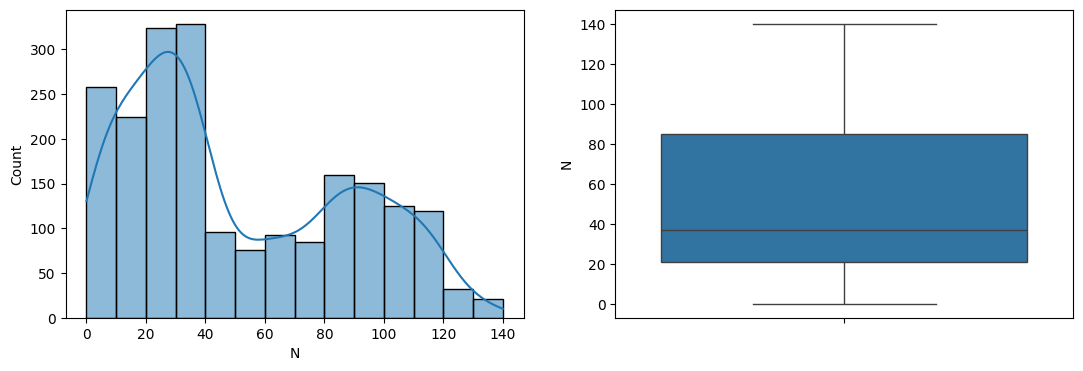

In [ ]:
plt.figure(figsize=(13,4))
plt.subplot(1,2,1)
sns.histplot(df["N"],kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["N"])
plt.show()

/tmp/ipykernel_1074/1950482534.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

5.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



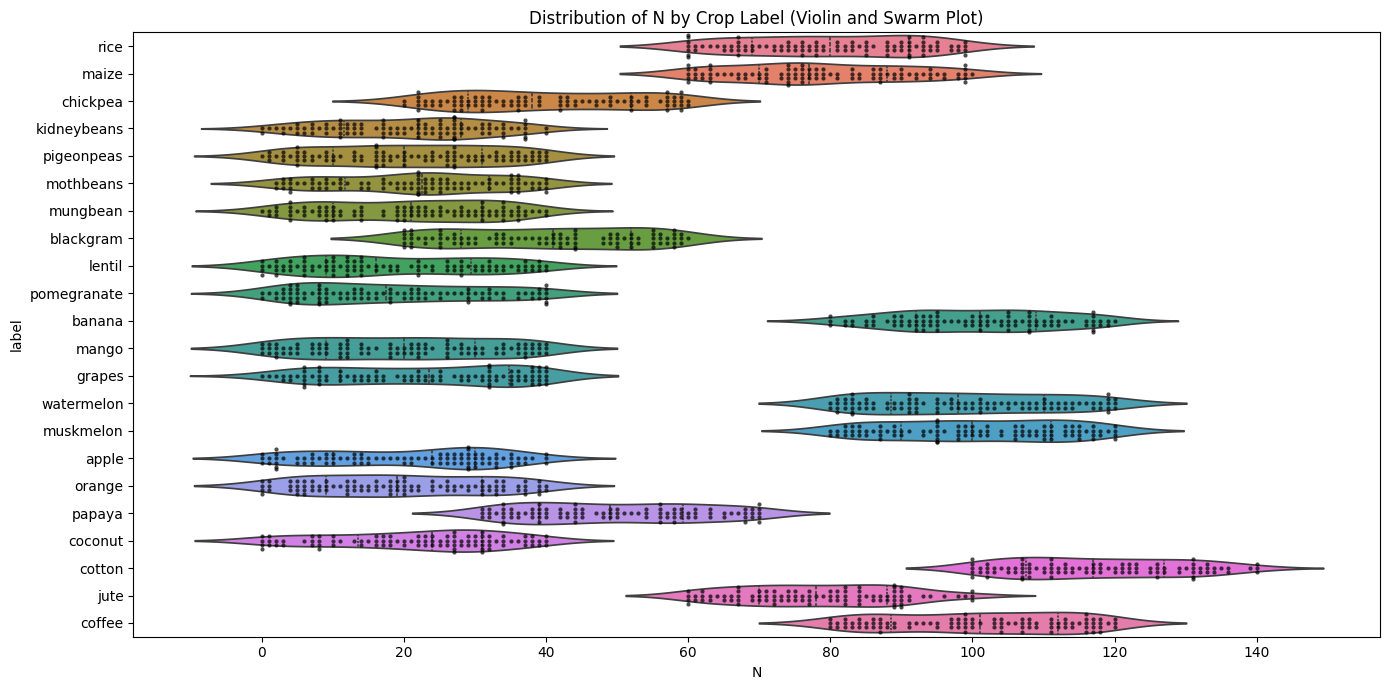

In [ ]:
#Violin + Swarm plot
plt.figure(figsize=(14, 7))
sns.violinplot(data=df, y="label", x="N", inner="quartile", palette="husl")
sns.swarmplot(data=df, y="label", x="N", color="k", alpha=0.7, size=3)
plt.title('Distribution of N by Crop Label (Violin and Swarm Plot)')
plt.tight_layout()
plt.show()

* The distribution of column N represents a bimodal distribution, as it shows two distinct peaks in the data.
This indicates the values are concentrated around two different ranges and **no significant outliers** are observed in this feature.
* The nitrogen values in the dataset show a wide distribution, indicating that different crops require varying levels of nitrogen in the soil for optimal growth.The presence of both low and high nitrogen levels suggests that some crops grow well in nitrogen-rich soils, while others require relatively lower nitrogen concentrations.Since nitrogen is an essential macronutrient for plant growth, its variation across crops indicates that soil nutrient composition plays a significant role in determining suitable crops for cultivation.
* The nitrogen distribution shows higher values for crops such as maize and rice or for some fruits, which are known to be nitrogen-demanding crops. The variation across crops suggests **realistic soil nutrient requirements** rather than uniform or artificial values.

# **Column 'P' analysis**

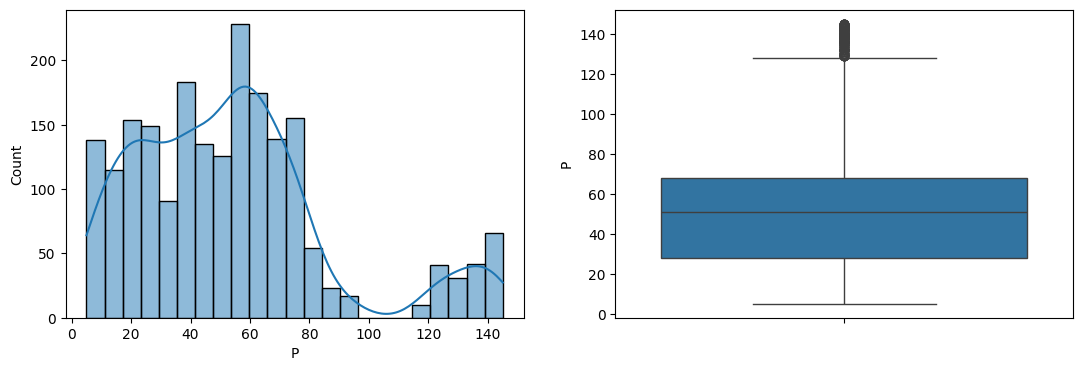

In [ ]:
plt.figure(figsize=(13,4))
plt.subplot(1,2,1)
sns.histplot(df["P"],kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["P"])
plt.show()

From the above plot, it appears that the column may contain some outliers. To confirm this observation, further some tests will be performed.

/tmp/ipykernel_1074/4209295417.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

6.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

5.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

8.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12

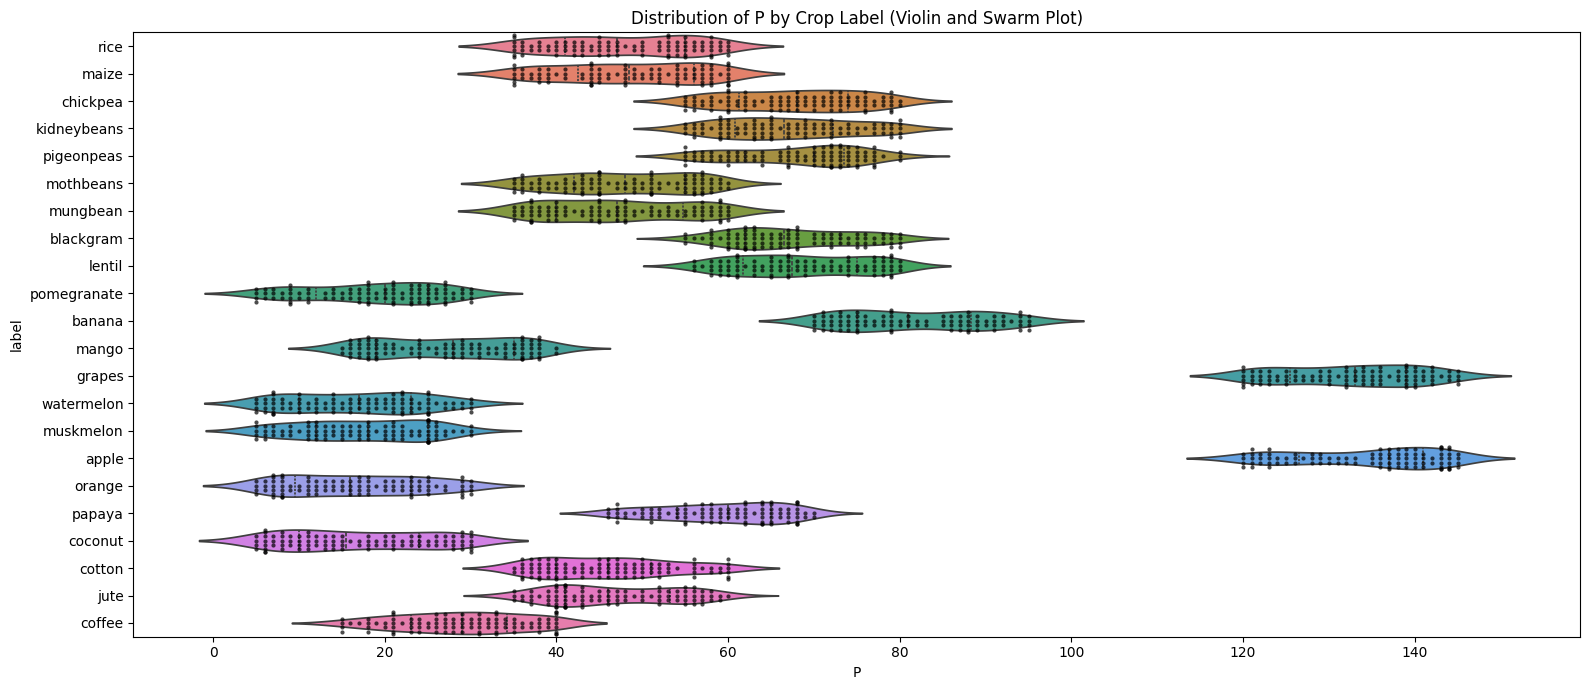

In [ ]:
#Violin + Swarm plot
plt.figure(figsize=(16, 7))
sns.violinplot(data=df, y="label", x="P", inner="quartile", palette="husl")
sns.swarmplot(data=df, y="label", x="P", color="k", alpha=0.7, size=3)
plt.title('Distribution of P by Crop Label (Violin and Swarm Plot)')
plt.tight_layout()
plt.show()

* From the above plot, it is evident that the elevated regions in the histogram, which initially **appeared to be outliers, actually represent a distinct class (apple , grapes ) with characteristics different from the others**. These values are part of the natural variation present in the dataset rather than anomalies. Upon further observation, these elevations correspond to specific groups within the data that possess different properties. Hence, they should not be treated as outliers or removed during preprocessing. Therefore, it can be concluded that the overall P column follow right-skewed (positively skewed) distribution, and no significant outliers are present in this feature.
* Most values are concentrated in the moderate phosphorus range, suggesting that many crops grow best in soils with balanced phosphorus availability.The variation in phosphorus levels helps the machine learning model understand nutrient requirements for different crops, improving crop recommendation accuracy.

# **Column 'K' analysis**

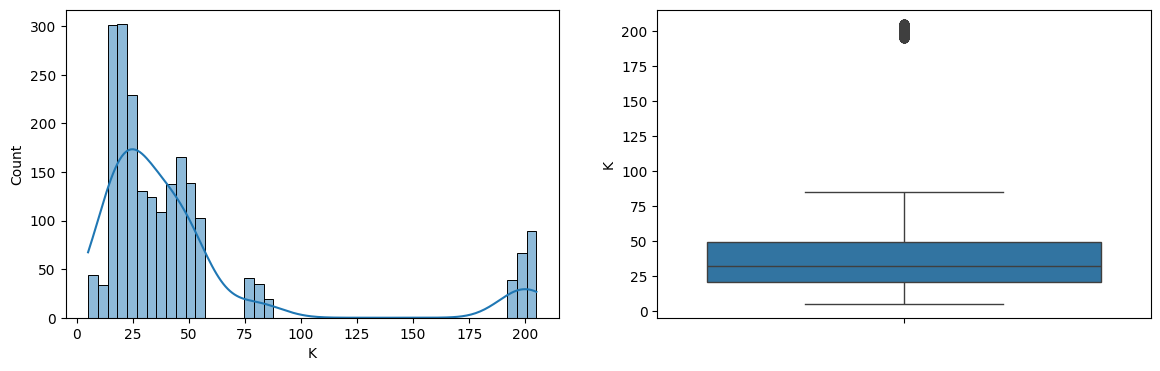

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(df["K"],kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["K"])
plt.show()

From the above plot, it appears that the column may contain some outliers. To confirm this observation, further some tests will be performed.

/tmp/ipykernel_1074/1215321275.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

43.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

42.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

44.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

41.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3

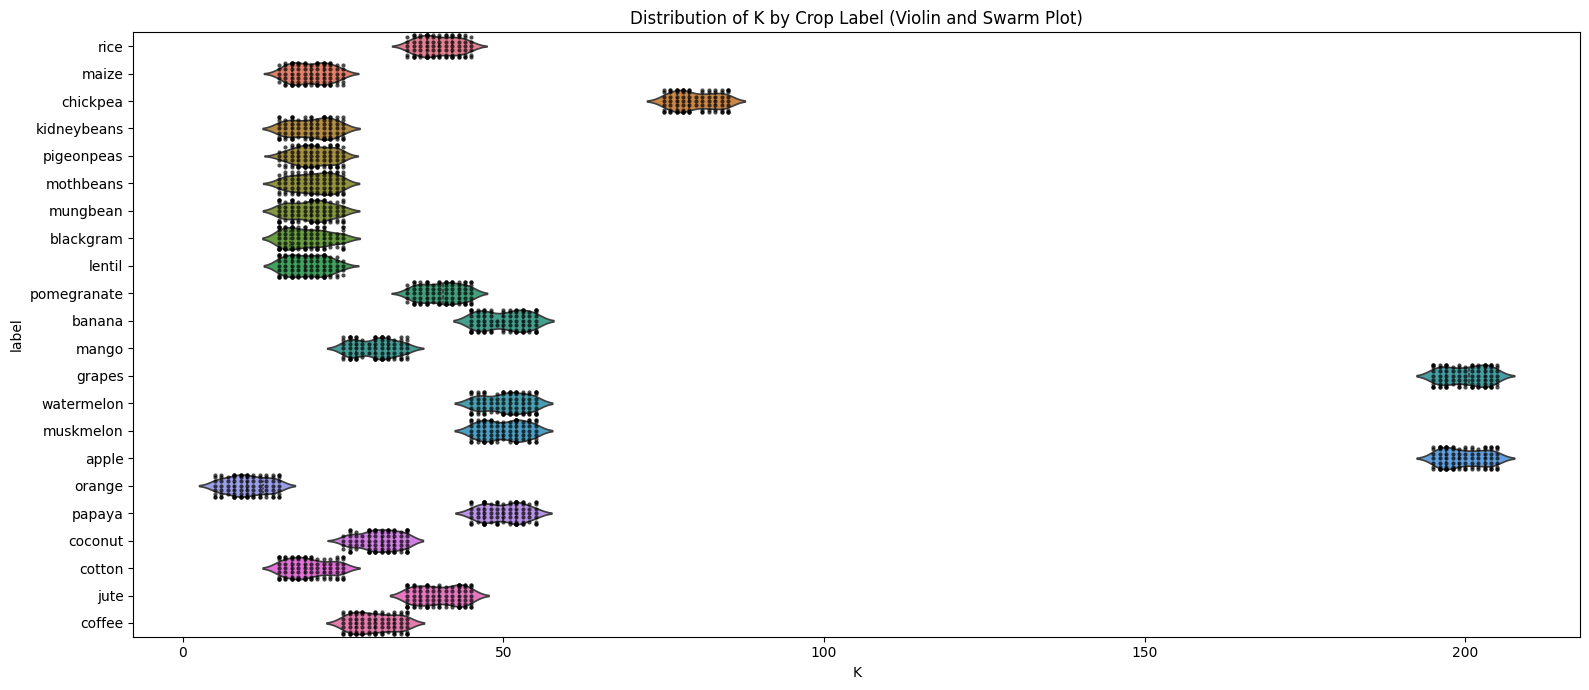

In [ ]:
#Violin + Swarm plot
plt.figure(figsize=(16, 7))
sns.violinplot(data=df, y="label", x="K", inner="quartile", palette="husl")
sns.swarmplot(data=df, y="label", x="K", color="k", alpha=0.7, size=3)
plt.title('Distribution of K by Crop Label (Violin and Swarm Plot)')
plt.tight_layout()
plt.show()

* From the above plot, it is evident that the elevated regions in the histogram, which initially **appeared to be outliers, actually represent a distinct class with characteristics different from the others**. These values are part of the natural variation present in the dataset rather than anomalies. Upon further observation, these elevations correspond to specific groups (grapes, apple , chickpea) within the data that possess different properties. Hence, they should not be treated as outliers or removed during preprocessing. Therefore, it can be concluded that the overall 'K' column does not follow any standard statistical distribution, and no significant outliers are present in this feature.
* The potassium values exhibit a wide range, indicating that crops have varying potassium requirements depending on their growth characteristics.The boxplot shows variability in potassium concentration, with some crops requiring higher potassium levels for better yield and plant health.

# **Column 'temperature' analysis**




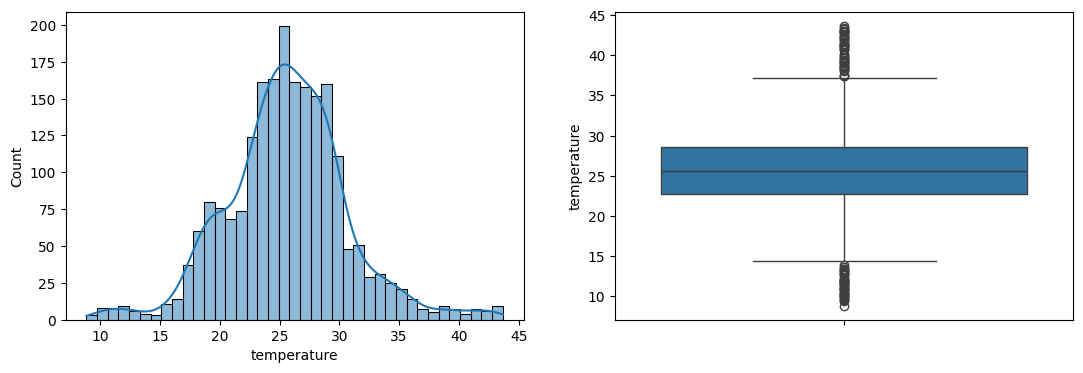

In [ ]:
plt.figure(figsize=(13,4))
plt.subplot(1,2,1)
sns.histplot(df["temperature"],kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["temperature"])
plt.show()

From the above plot, it appears that the column may contain some outliers. To confirm this observation, further some tests will be performed.

/tmp/ipykernel_1074/3848872538.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

28.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

33.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

8.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.1

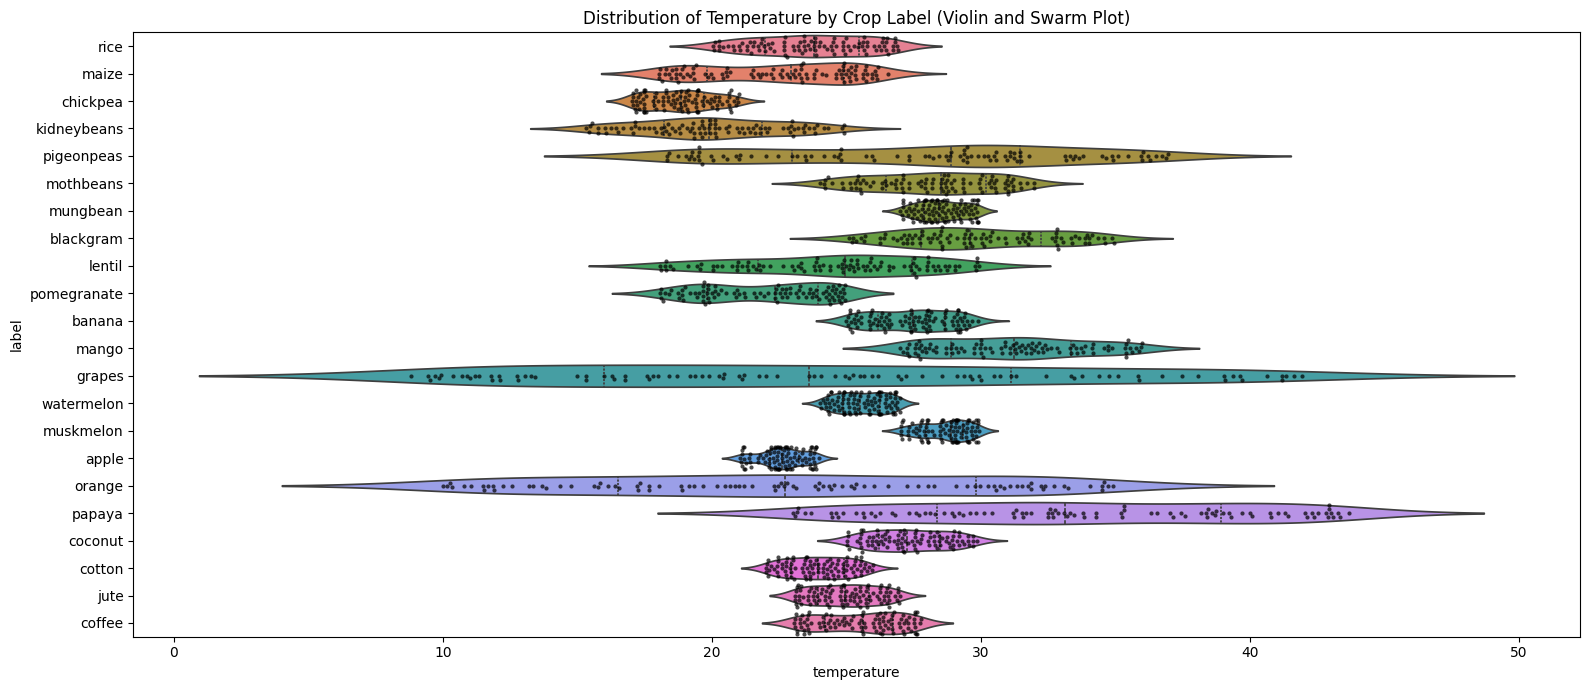

In [ ]:
#Violin + Swarm plot
plt.figure(figsize=(16, 7))
sns.violinplot(data=df, y="label", x="temperature", inner="quartile", palette="husl")
sns.swarmplot(data=df, y="label", x="temperature", color="k", alpha=0.7, size=3)
plt.title('Distribution of Temperature by Crop Label (Violin and Swarm Plot)')
plt.tight_layout()
plt.show()

* From this view, it is evident that there are **no true outliers** in the data. The seemingly extreme values represent the legitimate temperature requirements of specific crops and are therefore valid observations. Additionally, the overall temperature distribution appears to be approximately normal.
* The temperature values are mostly distributed within a moderate range, approximately 20°C to 30°C, indicating that the dataset includes crops grown under different climatic conditions.The relatively narrow spread of temperature values suggests that extreme temperatures are less common for the crops included in the dataset. The variation in temperature across crops indicates that temperature is an important environmental factor influencing crop suitability and growth.

# **Column  'humidity' analysis**

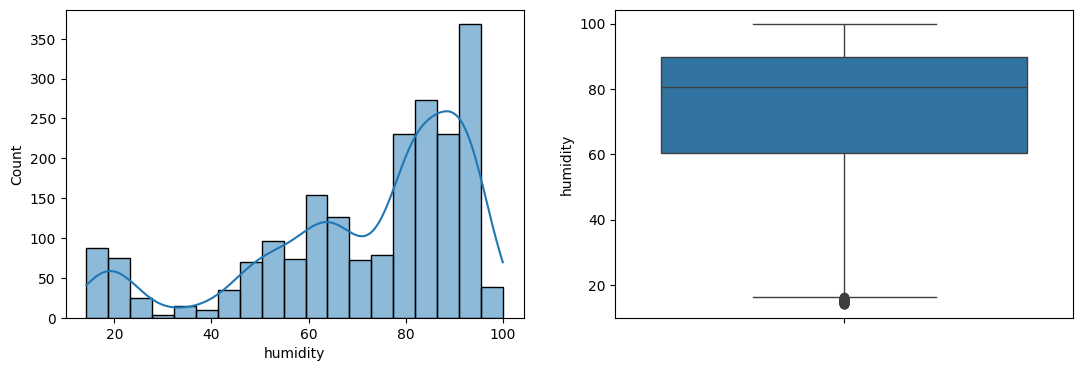

In [ ]:
plt.figure(figsize=(13,4))
plt.subplot(1,2,1)
sns.histplot(df["humidity"],kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["humidity"])
plt.show()

/tmp/ipykernel_1074/2533828464.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

40.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

27.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

24.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

13.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3

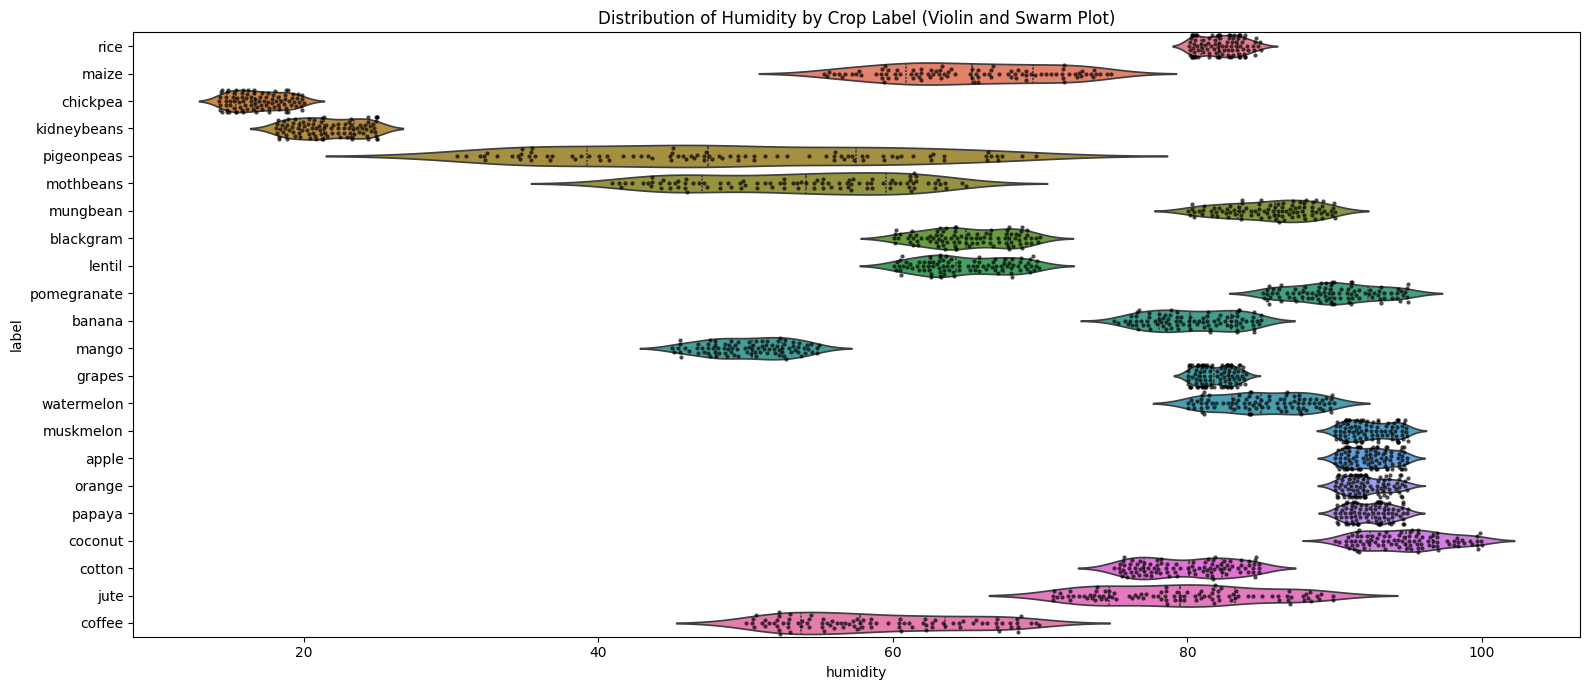

In [ ]:
#Violin + Swarm plot
plt.figure(figsize=(16, 7))
sns.violinplot(data=df, y="label", x="humidity", inner="quartile", palette="husl")
sns.swarmplot(data=df, y="label", x="humidity", color="k", alpha=0.7, size=3)
plt.title('Distribution of Humidity by Crop Label (Violin and Swarm Plot)')
plt.tight_layout()
plt.show()

* From the above plot, the data appears to contain potential outliers and shows a negatively skewed distribution with three peaks. However, the second plot clarifies that these values are **not true outliers but rather represent the natural characteristics of a specific crop class**.
* Most values are concentrated between 60% and 90% humidity, suggesting that many crops prefer moderate to high humidity environments for optimal growth.The KDE plot for different crops shows distinct humidity preference patterns, where certain crops cluster around specific humidity ranges, suggesting that humidity is an important factor in distinguishing crop types.

# **Column 'ph' analysis**

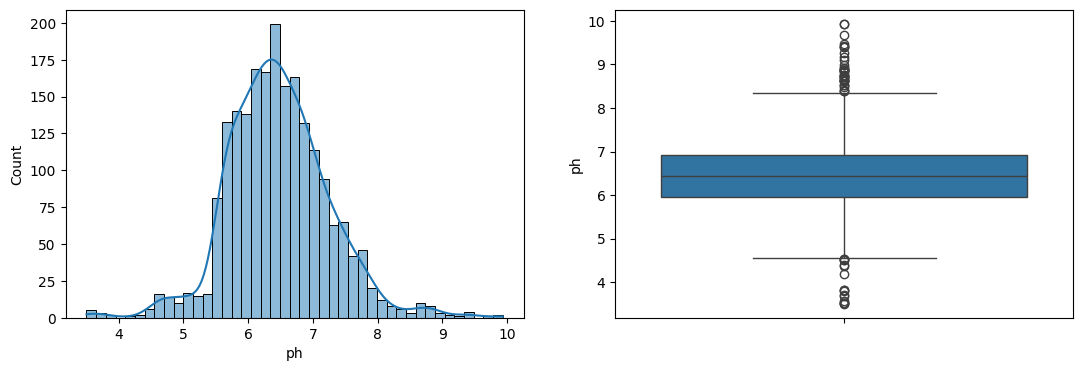

In [ ]:
plt.figure(figsize=(13,4))
plt.subplot(1,2,1)
sns.histplot(df["ph"],kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["ph"])
plt.show()

/tmp/ipykernel_1074/1321195470.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

9.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

41.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

11.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.

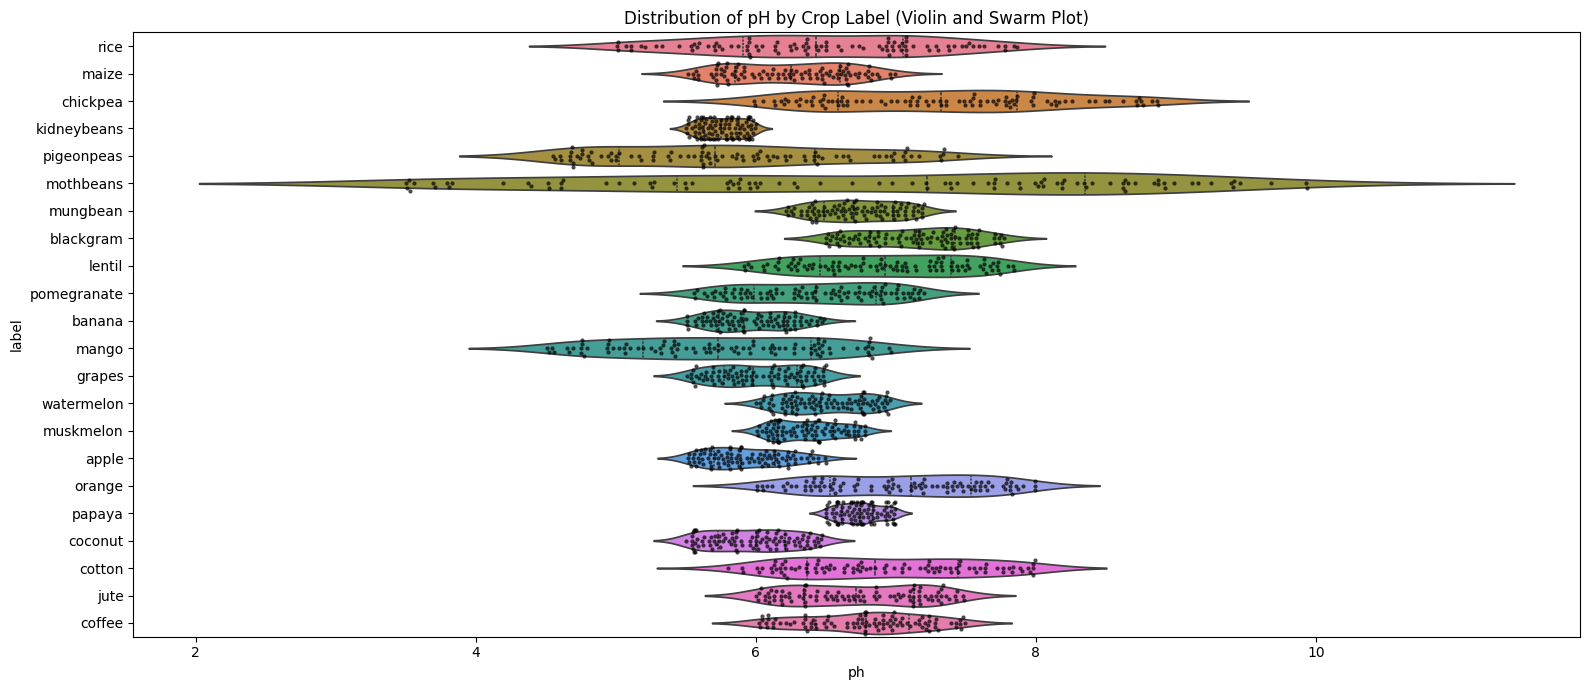

In [ ]:
#Violin + Swarm plot
plt.figure(figsize=(16, 7))
sns.violinplot(data=df, y="label", x="ph", inner="quartile", palette="husl")
sns.swarmplot(data=df, y="label", x="ph", color="k", alpha=0.7, size=3)
plt.title('Distribution of pH by Crop Label (Violin and Swarm Plot)')
plt.tight_layout()
plt.show()

* The pH values in the dataset are distributed within a relatively narrow range, indicating that most crops grow in slightly acidic to neutral soil conditions.When comparing pH across different crops, certain crops cluster around specific pH ranges, indicating that soil acidity plays an important role in determining suitable crops for cultivation.
* There are some statistical outliers, but they are very few. These values still lie within the possible pH range for soil, so they are not unrealistic errors.However, the second plot clarifies that these values are **not true outliers but rather represent the natural characteristics of a specific crop class**.


# **Column 'rainfall' analysis**

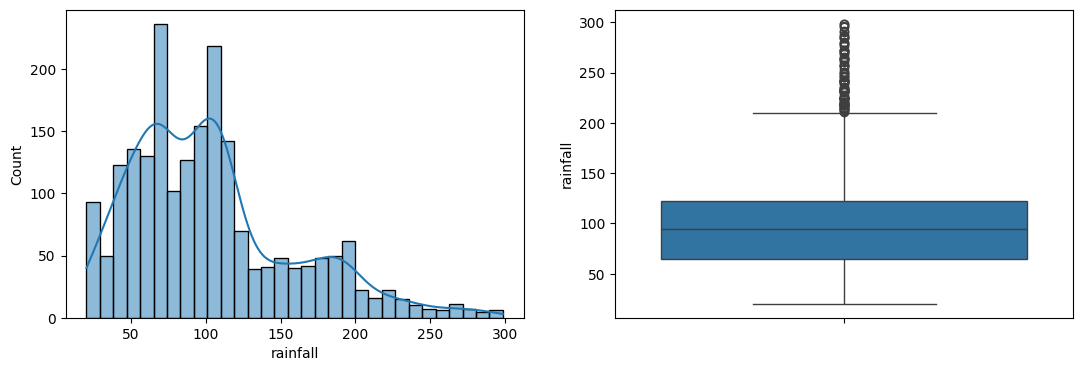

In [ ]:
plt.figure(figsize=(13,4))
plt.subplot(1,2,1)
sns.histplot(df["rainfall"],kde=True)
plt.subplot(1,2,2)
sns.boxplot(df["rainfall"])
plt.show()

/tmp/ipykernel_1074/507023890.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

20.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

10.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

28.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.1

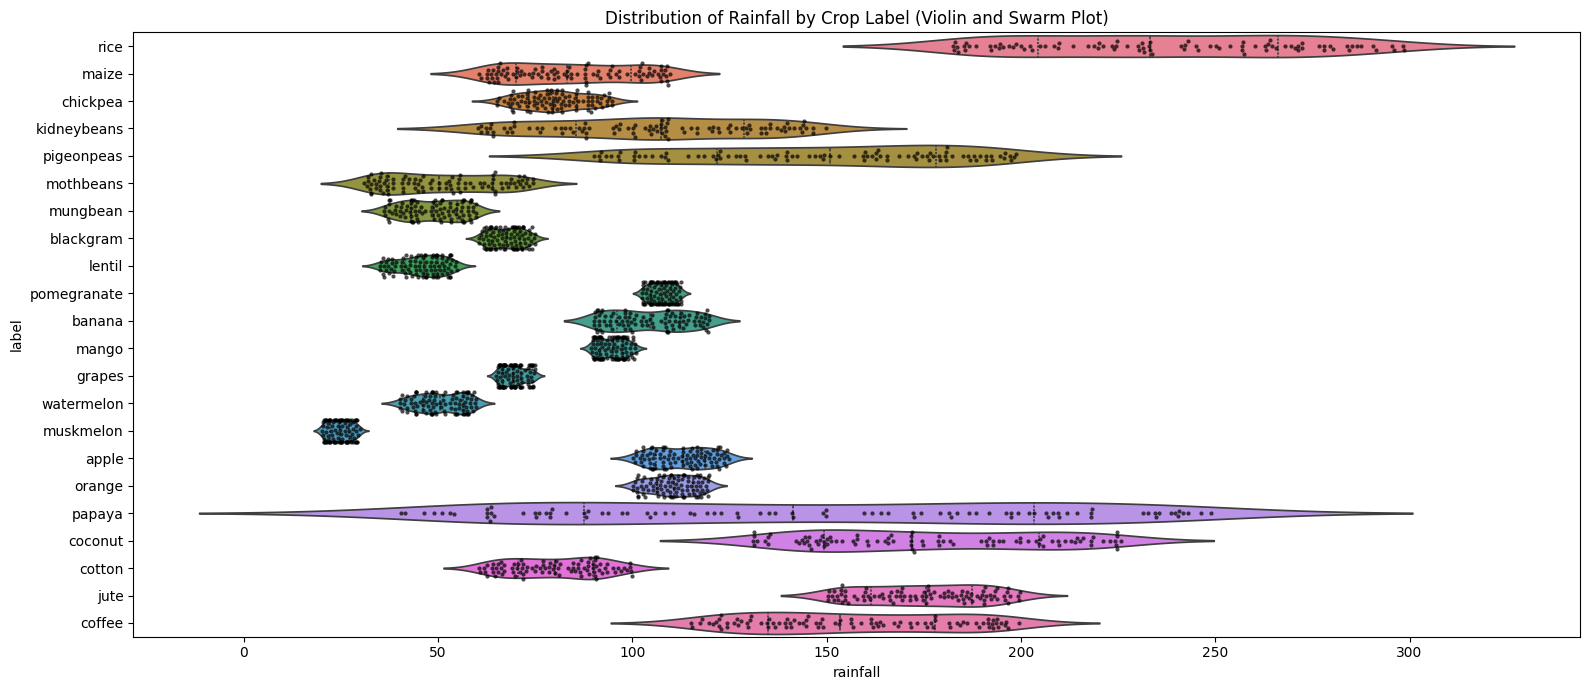

In [ ]:
#Violin + Swarm plot
plt.figure(figsize=(16, 7))
sns.violinplot(data=df, y="label", x="rainfall", inner="quartile", palette="husl")
sns.swarmplot(data=df, y="label", x="rainfall", color="k", alpha=0.7, size=3)
plt.title('Distribution of Rainfall by Crop Label (Violin and Swarm Plot)')
plt.tight_layout()
plt.show()

* From the above plot, the data appears to contain potential outliers and shows a right skewed distribution. However, the second plot clarifies that these values are **not true outliers but rather represent the natural characteristics of a specific crop class**.
* The rainfall values show a wide distribution, ranging from low rainfall levels to very high rainfall conditions, indicating diverse water requirements among crops.The variability in rainfall highlights that water availability plays a crucial role in determining suitable crops for cultivation.The presence of different rainfall ranges across crops indicates that rainfall is an important environmental parameter used by the model to distinguish between crop types.
* The rainfall distribution indicates that rice is associated with higher rainfall values, whereas crops such as chickpea and lentil appear in lower rainfall ranges. This **reflects real farming conditions where rice requires significant water availability**.

***Key Insights from Univariate Analysis:***
* **Crop prediction depends on nutrient balance, not single nutrients**:
Crops are defined by specific N-P-K combinations rather than individual nutrients, indicating realistic soil chemistry interactions.  
Example : Grapes → high P and K, not just one  ; Maize → high Nitrogen, moderate others, etc.
* **Crops are restricted to moderate temperature ranges**: Most crops lie within a 20-30°C range, indicating that extreme temperatures limit crop viability, which reflects real climatic constraints.  
Example : Rice, maize → mostly around 22-30°C ; Very few crops below 15°C or above 35°C.
* **Soil pH is centered around neutral levels**: The dataset shows most crops in the 6-7.5 pH range, where nutrient absorption is optimal, aligning with real soil conditions.  
Example : Wheat → ~6.5-7 ; Rice → ~5.5-7 (slightly acidic to neutral), etc.
* **Rainfall is the primary differentiator of crops**: The dataset shows clear clustering of crops based on rainfall, where water-intensive crops like rice appear in high rainfall regions, while crops like chickpea are found in lower rainfall ranges. This matches real-world agricultural zoning.  
Example : Rice → rainfall typically > 200 mm ; Chickpea → grows in low to moderate rainfall, etc.
* **Overlapping environmental conditions explain model errors** : Certain crops share similar environmental conditions, leading to overlapping feature spaces and classification confusion, which reflects real-world ambiguity.  
Example : Rice vs Maize → similar temperature ranges ; Papaya vs Orange → overlap in rainfall & humidity, etc.

> The dataset can be considered ***realistic*** because crop patterns follow known **agricultural principles**—such as rainfall dependency, moderate temperature constraints, and balanced soil nutrients—while also showing natural overlaps between crops, which reflects real-world farming conditions.





# **🔎Bivariate Analyis : Relation among Dataset Features**

In [ ]:
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

# Features for dropdowns
features = ['temperature', 'humidity', 'rainfall', 'N', 'P', 'K']

# Dropdown widgets
x_dropdown = widgets.Dropdown(options=features, value='temperature', description='X-Axis:')
y_dropdown = widgets.Dropdown(options=features, value='humidity', description='Y-Axis:')

out = widgets.Output()

def update_plot(change):
    with out:
        clear_output(wait=True)

        # Create scatter plot
        fig = px.scatter(
            df,
            x=x_dropdown.value,
            y=y_dropdown.value,
            color='label',  # color-coded by crop
            title=f"{y_dropdown.value.capitalize()} vs {x_dropdown.value.capitalize()}",
            height=650,
            width=1200,
            opacity=1,
            hover_data={x_dropdown.value: True, y_dropdown.value: True, 'label': True}
        )

        # Hide legend
        fig.update_layout(
            showlegend=False,
            plot_bgcolor="white",
            hovermode="closest",
            margin=dict(r=300)
        )

        # Customize hover for each trace
        for trace in fig.data:
            # Set the background of hover label same as trace color
            trace.hoverlabel = dict(
                bgcolor=trace.marker.color,  # dynamically set to crop color
                bordercolor="black",          # border for visibility
                font_size=13,
                font_family="Verdana",
                align="left"
            )
            # Set hover text
            trace.hovertemplate = (
                "<b>Crop:</b> %{customdata[0]}<br>"
                f"<b>{x_dropdown.value.capitalize()}:</b> %{{x}}<br>"
                f"<b>{y_dropdown.value.capitalize()}:</b> %{{y}}<extra></extra>"
            )

        # Axes styling
        fig.update_xaxes(showline=True, linewidth=1, linecolor='black', mirror=True,
                         showgrid=True, gridcolor='lightgrey')
        fig.update_yaxes(showline=True, linewidth=1, linecolor='black', mirror=True,
                         showgrid=True, gridcolor='lightgrey')

        fig.show()

# Observe dropdowns
x_dropdown.observe(update_plot, names='value')
y_dropdown.observe(update_plot, names='value')

# Initial plot
update_plot(None)

# Display widgets
display(widgets.HBox([x_dropdown, y_dropdown]))
display(out)

Output()



# **Bivariate Analysis & Feature Relationships**
# 1. Temperature vs. Humidity (The Climate Matrix)

-**Observation**: Crops heavily concentrate in a moderate 20–30°C temperature range paired with specific humidity levels.

-**Clustering**: Plants form tight, distinct groups based on these climate needs. Some are completely isolated in extreme humidity zones.

-**Model Impact**: These clear boundaries provide strict mathematical rules, allowing the algorithm to easily differentiate between crop classes.

# 2. Rainfall vs. Temperature (The Hydration Profile)

-**Observation**: While preferred temperatures overlap across crops, water needs vary drastically—from drought-resistant (20mm) to water-heavy (300mm).

-**Clustering**: Data groups neatly into distinct hydration zones. Temperature dictates if a plant grows, but rainfall determines which plant thrives.

-**Model Impact**: This massive variance acts as a powerful differentiator, helping the model instantly rule out incompatible crops.

# 3. Nitrogen (N) vs. Phosphorus (P) (Core Soil Nutrients)

-**Observation**: Different crops require highly specific, non-random combinations of these primary macronutrients.

-**Clustering**: Crops group into targeted zones (e.g., high Nitrogen but low Phosphorus). They only reach optimal yield within these exact bounds.

-**Model Impact**: This clear separation acts as a biological filter, allowing distance-based algorithms like K-Nearest Neighbors (KNN) to accurately classify crops based on nutrient proximity.

# 4. Nitrogen (N) vs. Potassium (K) (Independent Growth Factors)

-**Observation**: The distribution of N versus K is highly diverse and does not follow a strict linear trend.

-**Clustering**: High Nitrogen does not always mean high Potassium; these two nutrients influence crop growth independently.

-**Model Impact**: This independent variation is excellent for training. It provides nuanced data coordinates, preventing the model from treating the features as redundant.

# 5. Identical Feature Plots (e.g., Temperature vs. Temperature)

-**Observation**: Plotting a feature against itself always forms a perfect 45-degree diagonal line.

-**Significance**: Because every data point shares the exact same value on both axes (a correlation of exactly 1.0), this view acts as a baseline sanity check to confirm data alignment and structural integrity before model training.

While this dataset's seven numerical attributes allow for dozens of scatter plot combinations, plotting every possible pair would create analytical clutter. To maintain clarity, only the most scientifically informative pairs were selected. Focusing exclusively on these primary interactions keeps the exploratory data analysis concise, interpretable, and directly aligned with our predictive modeling goals.


## **Key Crop Classification Insights:**

- Grapes and Apples: Require high Phosphorus (P > 100) and high Potassium (K > 170).

- Chickpea: Needs moderately high Potassium (70 < K < 100).

- Papaya, Grapes, Oranges: Can grow across a wide temperature range.

- Mothbeans: Tolerant to a wide pH range.

- Rice, Papaya, etc.: Can survive across a wide range of rainfall.

# **Missing Value Analysis**

In [ ]:
# Identifying percentage of missing values for each attribute
df.isnull().mean()*100

,0
N,4.909091
P,5.818182
K,4.181818
temperature,3.500000
humidity,6.181818
ph,5.000000
rainfall,5.500000
label,0.000000


In [ ]:
# Total no. of missing values for each attribute and percentage of missing values in entire dataset
print('No. of Missing values for each attribute : ')
print(df.isnull().sum())
total_missing_values = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
percentage_missing = (total_missing_values / total_cells) * 100
print('Total number of missing values in the dataset:', total_missing_values)
print(f'Percentage of total missing values in the entire dataset: {percentage_missing:.2f}%')

No. of Missing values for each attribute : 
N              108
P              128
K               92
temperature     77
humidity       136
ph             110
rainfall       121
label            0
dtype: int64
Total number of missing values in the dataset: 772
Percentage of total missing values in the entire dataset: 4.39%


In [ ]:
# Identifying no. of rows with different no. of missing values
missing_counts = df.isnull().sum(axis=1)
rows_with_multiple_nans = missing_counts[missing_counts > 1]

print(f"Number of rows with more than one NaN: {len(rows_with_multiple_nans)}")
print("\nDistribution of NaN counts:")
print(missing_counts.value_counts().sort_index())

Number of rows with more than one NaN: 94

Distribution of NaN counts:
0    1529
1     577
2      87
3       7
Name: count, dtype: int64


> **<h3>Missing Values Heatmap</h3>**


In [ ]:
import plotly.graph_objects as go

# 1. Convert the True/False missing values into 1s and 0s for Plotly to read
missing_data = df.isnull().astype(int)

# 2. Create the Heatmap
fig = go.Figure(data=go.Heatmap(
    z=missing_data,
    x=df.columns,
    y=df.index,
    # Custom colors: 0 (False) is white, 1 (True) is red
    colorscale=[[0, 'black'], [1, 'gold']],
    showscale=False, # This perfectly replicates your cbar=False
    # Custom hover text so it's easy to read
    hovertemplate="Row Index: %{y}<br>Column: %{x}<br>Missing Status : %{z}<extra></extra>"
))

# 3. Clean up the layout
fig.update_layout(
    title="Missing Values Heatmap",
    xaxis_title="Columns",
    yaxis_title="Row Index",
    width=1000,
    height=500,
    plot_bgcolor="white",
    hovermode="closest"
)

# 4. Match Seaborn's layout
# Seaborn puts Row 0 at the top of the graph. Plotly defaults to putting 0 at the bottom.
# This line reverses it so it perfectly matches your original plot's orientation!
fig.update_yaxes(autorange="reversed")

fig.show()

The missing values heatmap visualizes the distribution of missing data across the dataset. The missing values are sparsely and randomly distributed across the feature columns. Additionally, the target variable (label) does not contain any missing values, ensuring that the dataset remains suitable for classification tasks.

> **<h3>Key Insights from Missing Value Analysis</h3>**
* The dataset contains approximately 4.4% missing values across the feature columns, which represents a relatively small portion of the overall data.

* The missing values are **distributed randomly** across different rows and columns, indicating that the missingness does not follow any specific pattern.

* The target variable (label) does not contain any missing values, which ensures that the dataset remains suitable for training classification models.





Based on the above discussion, it can be inferred that imputing missing values using simple statistical measures such as the mean or median may not produce reliable results. This is because the data does not follow a standard distribution and contains variations that are specific to different crop classes. Using **mean or median could distort these natural patterns and reduce the quality of the dataset**. Therefore, we can use other suitable approach like
- KNN imputation, which estimates missing values based on the similarity between data points. By considering the nearest neighbors, **KNN preserves the underlying structure and relationships within the data**, making it a more effective method for imputing missing values in this dataset
- **Imputing with group-wise mean method**

#**Missing Value Imputation using KNN**

In [ ]:
from sklearn.model_selection import train_test_split
df_train,df_test= train_test_split(df,test_size=0.3,random_state=42)
d1_train=df_train.copy()
d1_test=df_test.copy()

In [ ]:
d1_train = df_train.copy()
d1_test = df_test.copy()

features = ['N','P','K','temperature','humidity','ph','rainfall']

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

d1_train[features] = imputer.fit_transform(d1_train[features])
d1_test[features] = imputer.transform(d1_test[features])

d1_imputed = pd.concat([d1_train, d1_test], axis=0)

# **Missing value imputation using groupwise mean method**

In [ ]:
d2_train=df_train.copy()
d2_test=df_test.copy()

features = ['N','P','K','temperature','humidity','ph','rainfall']

# 1️⃣ Calculate group-wise mean in training set
group_means = d2_train.groupby('label')[features].mean()

# 2️⃣ Function to impute missing values row by row based on label
def impute_by_label(row, group_means):
    label = row['label']
    for col in features:
        if pd.isna(row[col]):
            row[col] = group_means.loc[label, col]  # fill with crop-wise mean
    return row

# 3️⃣ Apply to training and test sets
d2_train = d2_train.apply(lambda row: impute_by_label(row, group_means), axis=1)
d2_test = d2_test.apply(lambda row: impute_by_label(row, group_means), axis=1)

d2_imputed=pd.concat([d2_train,d2_test],axis=0)

Applied Two Imputation Methods:

* **KNN Imputation (D1):** We used KNNImputer to fill missing values based on the values of the 5 nearest neighbors. This method imputes values by looking for similar data points in the feature space.

* **Group-wise Mean Imputation (D2)**: We calculated the mean of each feature for each specific crop label in the training data. Missing values were then filled using the mean corresponding to their respective crop type. This method accounts for the unique characteristics of each crop.
* Both KNN and Group-wise Mean imputation successfully filled the missing data while largely preserving the overall statistical distributions and underlying correlation patterns of the features. The imputed dataset retains meaningful patterns that allow algorithms such as KNN classifier to learn effectively from the data.

# Checking and comparing effect of imputation

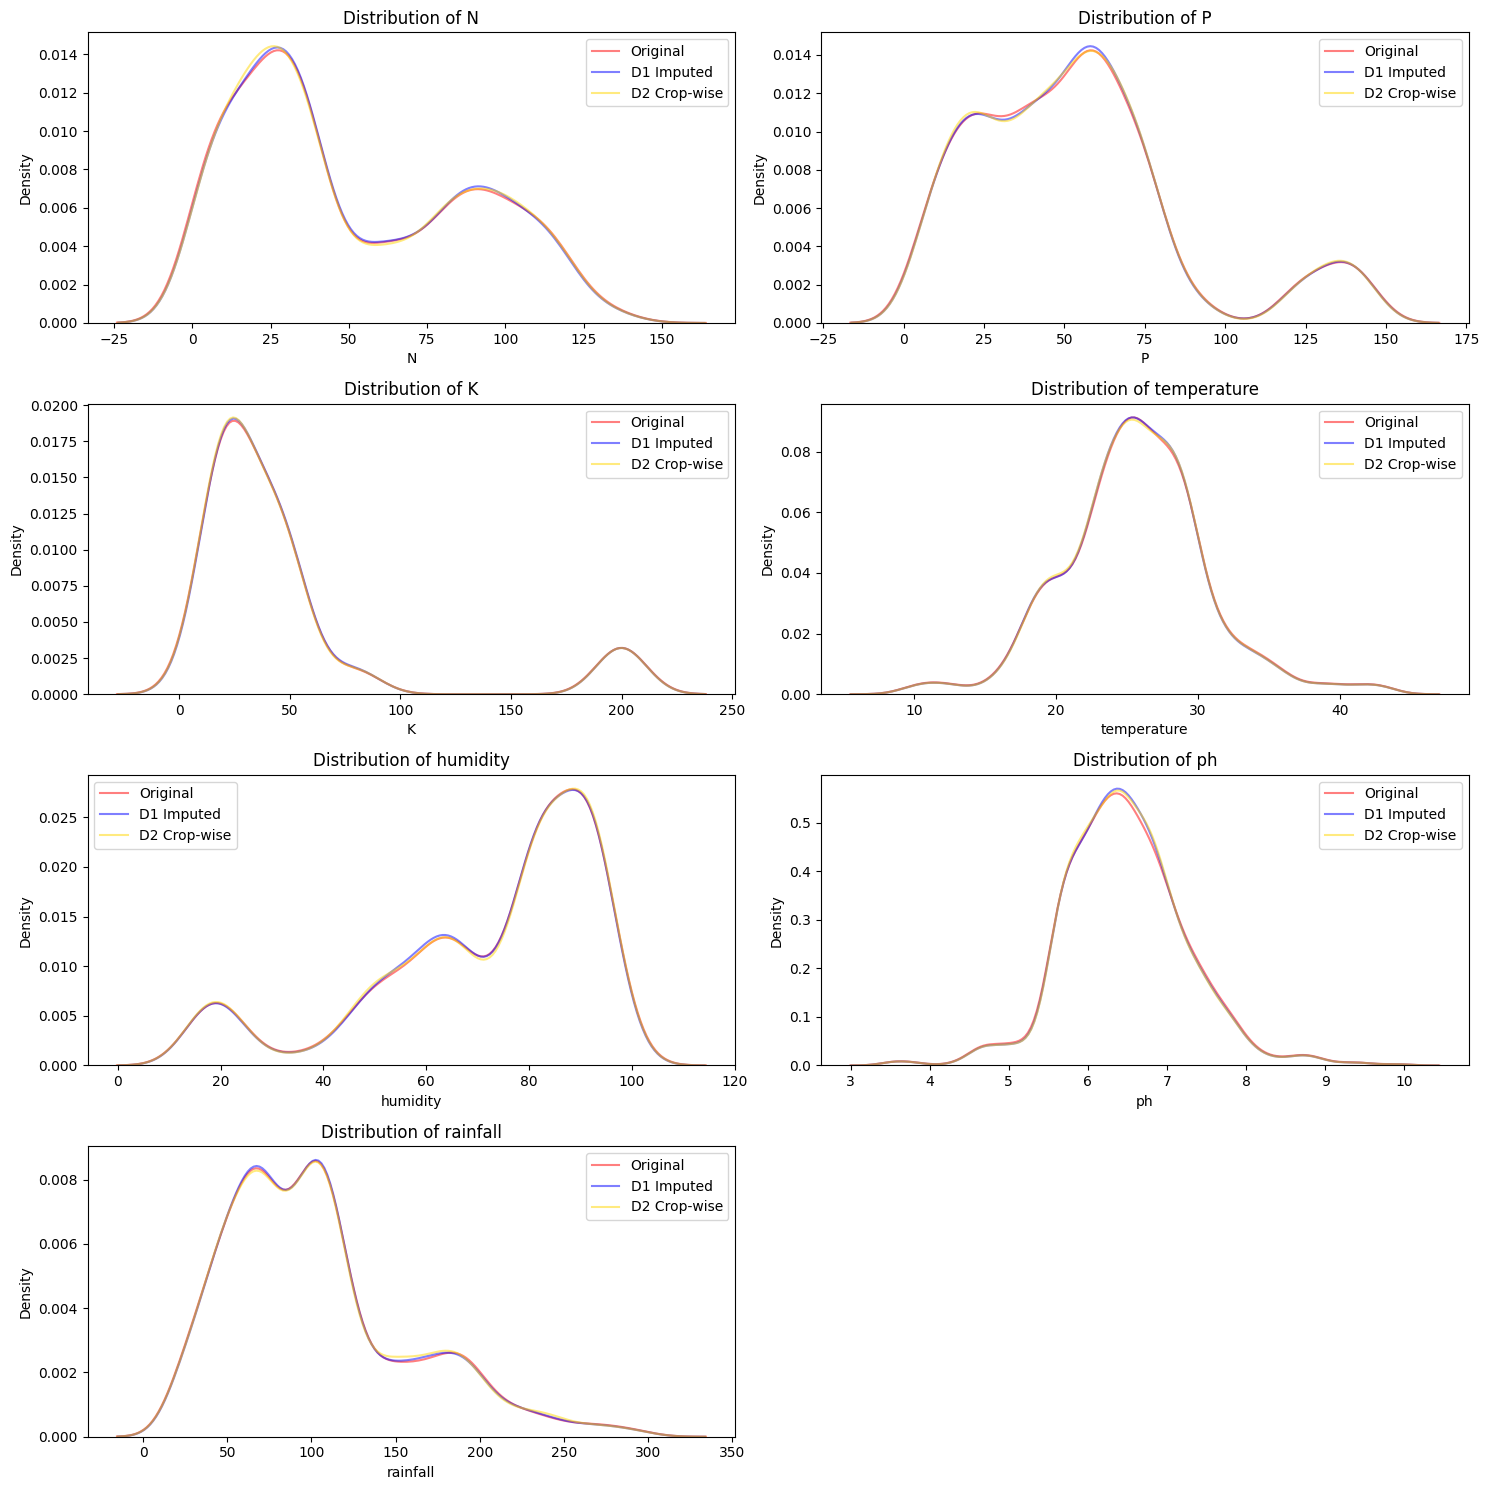

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

# Adjust figure size for 3 rows x 2 columns
plt.figure(figsize=(15, 15))

for i, col in enumerate(features):
    plt.subplot(4, 2, i + 1)

    # Original
    sns.kdeplot(Original_dataset[col], color='red', label='Original', alpha=0.5)

    # D1 Imputed
    sns.kdeplot(d1_imputed[col], color='blue', label='D1 Imputed', alpha=0.5)

    # D2 Crop-wise Imputed
    sns.kdeplot(d2_imputed[col], color='gold', label='D2 Crop-wise', alpha=0.5)

    plt.title(f'Distribution of {col}')
    plt.legend()

plt.tight_layout()
plt.show()


* The pdf comparison between original and imputed attributes shows that the overall distribution remains nearly unchanged after imputation. This indicates that the **imputation method preserved the natural statistical characteristics of the dataset**.
* The shape of the distribution (skewness and spread) remains similar before and after imputation, suggesting that the imputed values are consistent with the existing data patterns.
* By filling missing values instead of removing rows, all data samples were retained, allowing the machine learning model to learn from the complete dataset.



# Correlation Analysis along with different imputation model performace

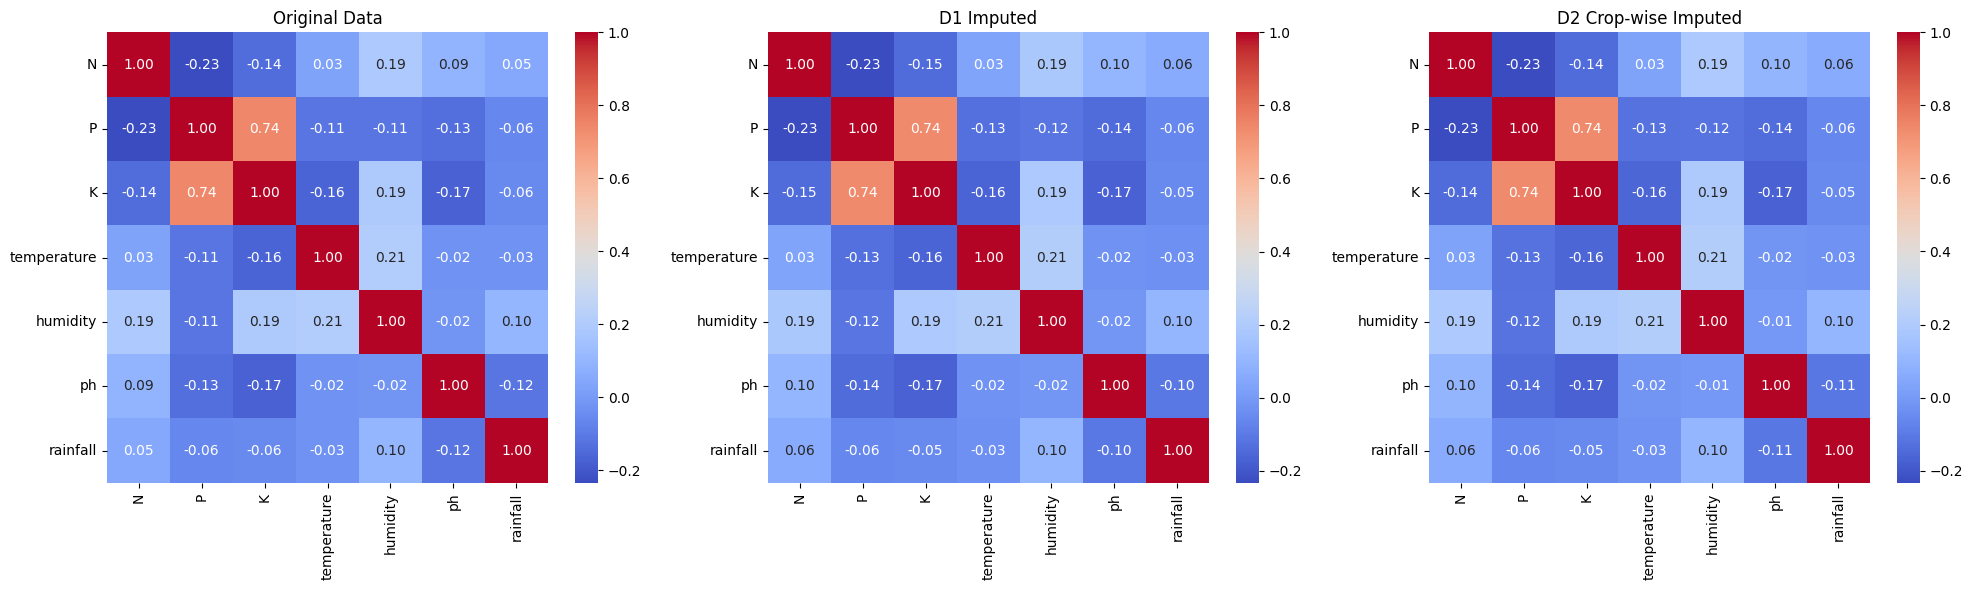

In [ ]:
features = ['N','P','K','temperature','humidity','ph','rainfall']  # columns to compare

corr_original = df[features].corr()
corr_d1 = d1_imputed[features].corr()
corr_d2 = d2_imputed[features].corr()

# Set up the figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Plot original correlation
sns.heatmap(corr_original, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, ax=axes[0])
axes[0].set_title("Original Data")

# Plot D1 imputed correlation
sns.heatmap(corr_d1, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, ax=axes[1])
axes[1].set_title("D1 Imputed")

# Plot D2 crop-wise imputed correlation
sns.heatmap(corr_d2, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, ax=axes[2])
axes[2].set_title("D2 Crop-wise Imputed")

plt.tight_layout()
plt.show()

* From the correlation analysis, it is evident that among all features, Potassium (K) and Phosphorus (P) show the strongest correlation (≈0.74) with each other, while the correlations among the other features are very weak. This indicates that K and P tend to vary together in the dataset, whereas other features are **largely independent**. These insights can help in understanding the relationships among soil nutrients
*  Both KNN and Group-wise Mean imputation methods successfully preserved these original correlation patterns without distortion, ensuring the data's integrity for subsequent modeling.

# **Creating a Predictive model using KNN classifier**

# Pre processing and model training

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def prepare_and_train_knn(df_train, df_test, features, target, k_values):

    # Label encoding
    le = LabelEncoder()
    le.fit(df_train[target])
    df_train[target] = le.transform(df_train[target])
    df_test[target] = le.transform(df_test[target])

    # Split features and target
    x_train, y_train = df_train[features], df_train[target]
    x_test, y_test = df_test[features], df_test[target]

    # Scale features
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    # Train KNN for each k and store accuracy
    accuracy_list = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(x_train_scaled, y_train)
        acc = accuracy_score(y_test, knn.predict(x_test_scaled))
        accuracy_list.append(acc)

    return accuracy_list, le, x_train_scaled, x_test_scaled, y_train, y_test

In [ ]:
features = ['N','P','K','temperature','humidity','ph','rainfall']
target = 'label'
k_values = list(range(1,16,2))

knn_accuracy1, le1, x1_train, x1_test, y1_train, y1_test = prepare_and_train_knn(d1_train, d1_test, features, target, k_values)
knn_accuracy2, le2, x2_train, x2_test, y2_train, y2_test = prepare_and_train_knn(d2_train, d2_test, features, target, k_values)


In [ ]:
import plotly.express as px

# Make sure k_values is defined
k_values = list(range(1,16,2))

# Create a DataFrame for plotting two lines (D1 vs D2)
df_acc = pd.DataFrame({
    "K Value": k_values + k_values,                  # repeat K values for both datasets
    "Accuracy": knn_accuracy1 + knn_accuracy2,      # separate accuracies
    "Model": ["D1 KNN"]*len(k_values) + ["D2 Group-wise"]*len(k_values)  # label each line
})


fig = px.line(df_acc, x="K Value", y="Accuracy", color="Model", markers=True, title="KNN Accuracy Comparison")

best_index1 = np.argmax(knn_accuracy1)
best_index2 = np.argmax(knn_accuracy2)

fig.add_scatter(x=[k_values[best_index1]], y=[knn_accuracy1[best_index1]], mode="markers+text",
                text=[f"Best K (D1)={k_values[best_index1]}"], textposition="top center",
                marker=dict(size=12, color='blue'), showlegend=False)

fig.add_scatter(x=[k_values[best_index2]], y=[knn_accuracy2[best_index2]], mode="markers+text",
                text=[f"Best K (D2)={k_values[best_index2]}"], textposition="top center",
                marker=dict(size=12, color='orange'), showlegend=False)

fig.update_layout(width=850, height=450, template="plotly_white", hovermode="x unified")
fig.update_traces(line=dict(width=3), marker=dict(size=8))
fig.update_xaxes(tickvals=k_values)
fig.update_yaxes(showgrid=True)

fig.show()


* Group-wise mean imputation consistently achieves higher accuracy than KNN imputation. This suggests that preserving crop-specific environmental patterns improves classification performance.
* The optimal number of neighbors changes depending on the imputation method, indicating that the quality of the imputed data directly affects the neighborhood structure used by the KNN classifier.
* Increasing the number of neighbors leads to lower accuracy because larger K values include more distant samples, which may belong to different crop classes, reducing classification precision.
*


In [ ]:
from sklearn.metrics import confusion_matrix

knn_final = KNeighborsClassifier(n_neighbors=3)
knn_final.fit(x2_train, y2_train)
y_pred = knn_final.predict(x2_test)



In [ ]:
print("accuracy_Score : ", accuracy_score(y2_test, y_pred))

accuracy_Score :  0.9681818181818181


- Although the KNN model achieved the highest accuracy when the number of neighbors was set to k = 1, this value was not selected because it tends to cause overfitting, as the model becomes highly sensitive to individual data points and noise in the dataset.
- The value k = 2 was also avoided because an even number of neighbors can lead to tie situations during the voting process, which may result in ambiguous classification decisions.
- Therefore, k = 3 was chosen as the optimal value, as it provides a better balance between model stability and generalization while reducing the risk of overfitting.

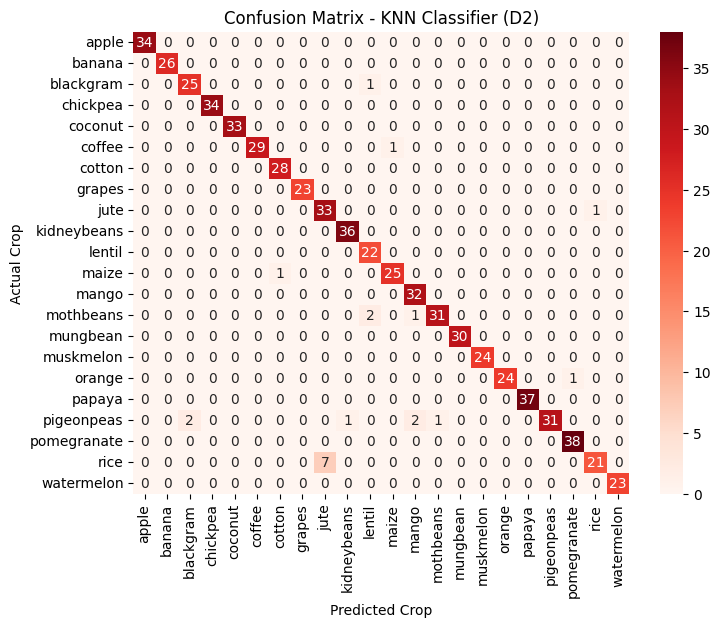

In [ ]:
# checking where is my model doing most of the mistakes
cm = confusion_matrix(y2_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=le2.classes_, yticklabels=le2.classes_)
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.title("Confusion Matrix - KNN Classifier (D2)")
plt.show()

* The confusion matrix demonstrates that the KNN classifier performs exceptionally well, with most predictions concentrated along the diagonal, indicating high classification accuracy across the majority of crops. This suggests that the dataset contains well-defined feature patterns for many crops, allowing effective separation in feature space.
* However, a few crops such as rice, mothbeans, and pigeonpeas exhibit minor misclassifications. These errors are not random but occur due to overlapping environmental characteristics like rainfall, temperature, and soil conditions.
* Some crops such as blackgram, chickpea, coffee, and maize are occasionally misclassified into each other because these crops likely share similar values of rainfall, temperature and humidity. A relatively higher number of rice samples are misclassified as jute because both crops require high rainfall and high humidity.
* Since KNN relies on distance-based similarity, it struggles when different crop classes share similar feature values, leading to confusion near class boundaries.

**<h3>Insights from Predictive model :</h3>**

* The **KNN classifier** achieved high prediction **accuracy (around 96.5%)**, indicating that the dataset contains clear patterns that allow crops to be distinguished based on soil nutrients and environmental conditions.
* The dataset with **group-wise mean imputation (D2)** consistently produced **slightly higher accuracy** than the dataset with **KNN imputation (D1)**. This indicates that imputing missing values using category-based statistics preserves important structural patterns in the dataset, helping the classifier identify more meaningful neighbors.
* Since KNN is a distance-based algorithm, the preprocessing steps such as **feature scaling and missing value imputation** help ensure that all attributes contribute fairly to the distance calculation.
* The **confusion matrix illustrates the performance of the KNN classifier** in predicting the appropriate crop based on the input features. The **majority of predictions lie along the diagonal** of the matrix, indicating that the model correctly classifies most crop samples.
* The **minor misclassifications observed in the confusion matrix are mainly due to overlapping feature** distributions among some crops. Crops that grow under similar soil nutrient levels and climatic conditions may have very similar feature values, causing the KNN algorithm to classify them into neighboring crop categories.
> **The strong performance of the KNN model demonstrates that crop types can be effectively predicted using soil nutrient levels and environmental factors, highlighting the usefulness of machine learning in agricultural recommendation systems.**

# **Key Insights :**
> **Importance of Exploratory Data Analysis** :
* EDA helped in understanding feature distributions, detecting relations between different variables, and verifying outliers. This step is essential because machine learning models are sensitive to data quality and feature distributions.

> **Impact of Missing Value Imputation** :
* Although the dataset originally contained missing values, the model still achieved strong performance after imputation. This suggests that the dataset is relatively robust, and the missing values did not significantly disrupt the overall data structure.
* The choice of imputation method affects the underlying structure of the dataset. Group-wise mean imputation maintains category-specific patterns, while KNN imputation considers similarity between samples, which can sometimes produce more realistic estimates.

> **Insights from model** :
* The final KNN model achieved its best performance at the selected optimal value of K, as observed from the accuracy vs K analysis. This indicates that the model was able to capture meaningful patterns in the dataset without overfitting to noise.
* Another important observation is that the dataset with group-wise mean imputation (D2) consistently achieves higher accuracy than the dataset with KNN imputation (D1). This suggests that imputing missing values based on the mean of similar crop groups preserves the inherent structure of the data more effectively, which helps the KNN classifier identify more meaningful nearest neighbors. This indicates that the dataset has category-specific patterns, where values within the same group tend to follow similar distributions.

> **Final Takeaway :**
* The study highlights how preserving meaningful data patterns through proper preprocessing and imputation can improve model reliability and allow similarity-based algorithms to effectively capture real-world relationships in the dataset.